# Hopf Oscillator Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Hopf Oscillator system using the multi-trajectory (Part 1) workflow.

## Governing equations

The Hopf oscillator dynamics are

$$
\begin{align*}
\dot{x} &= \mu x - \omega y - (x^2 + y^2)x, \\
\dot{y} &= \omega x + \mu y - (x^2 + y^2)y,
\end{align*}
$$

where $\mu$ is the bifurcation parameter and $\omega$ is the angular frequency.

We use parameters $(\mu,\omega)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.hopf import (
    HopfMultiTrajectoryGLSConfig,
    generate_hopf_dataset,
    run_hopf_multi_trajectory_gls_experiment,
)
from mfsindy.cases.hopf_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]


In [2]:
cfg = HopfMultiTrajectoryGLSConfig(
    n_runs=25,
    results_dir=str(RESULTS_DIR),
    results_filename="hopf_part1_errors.csv",
    T_train=0.1,
)

print(
    f"Running Part 1 Hopf Oscillator experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _,
    _,
    _,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_hopf_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)



Running Part 1 Hopf Oscillator experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Hopf MF:   0%|          | 0/25 [00:00<?, ?it/s]

MODEL HF:
(x0)' = -1.299 x0 x1^2
(x1)' = -1.221 x1^3
MODEL LF:
(x0)' = -0.986 x0^3 + -0.971 x0 x1^2
(x1)' =  1.239 x0 + -0.870 x0^2 x1 + -0.653 x1^3
MODEL MF:
(x0)' =  1.988 x0 + -1.021 x0^3 + -1.036 x0 x1^2
(x1)' =  1.247 x0 + -0.883 x0^2 x1 + -0.659 x1^3


Monte Carlo Hopf MF:   4%|▍         | 1/25 [01:11<28:26, 71.11s/it]

MODEL MFW:
(x0)' =  1.073 x0 + -1.067 x1 + -0.992 x0^3 + -1.006 x0 x1^2
(x1)' =  1.047 x0 +  1.075 x1 + -1.006 x0^2 x1 + -1.040 x1^3
MODEL HF:
(x0)' =  0.000
(x1)' = -0.971 x1^3
MODEL LF:
(x0)' = -0.842 x0^3
(x1)' =  0.897 x0 x1 + -1.256 x0^2 x1 + -0.693 x1^3
MODEL MF:
(x0)' = -0.983 x0^3
(x1)' =  0.818 x0 x1 + -1.190 x0^2 x1 + -0.683 x1^3


Monte Carlo Hopf MF:   8%|▊         | 2/25 [02:06<23:40, 61.78s/it]

MODEL MFW:
(x0)' =  0.803 x0 + -0.997 x1 + -0.960 x0^3 + -0.956 x0 x1^2
(x1)' =  0.934 x0 +  0.851 x1 + -0.968 x0^2 x1 + -0.980 x1^3
MODEL HF:
(x0)' =  0.000
(x1)' =  0.000
MODEL LF:
(x0)' = -0.531 x0^3 + -1.489 x0 x1^2
(x1)' = -0.547 x1^3


Monte Carlo Hopf MF:   8%|▊         | 2/25 [02:34<29:38, 77.32s/it]


KeyboardInterrupt: 

In [ ]:
print("Mean Absolute Error")
print(mae_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.362944  0.347794  0.390572
LF     0.280577  0.267266  0.327368
MF     0.288074  0.264684  0.326877
MF_w   0.019114  0.015071  0.024380


In [ ]:
print("Support Fraction Error")
print(l0_summary)


Active Support Error
         median       q25       q75
model                              
HF     0.333333  0.333333  0.388889
LF     0.222222  0.222222  0.222222
MF     0.222222  0.222222  0.222222
MF_w   0.000000  0.000000  0.000000


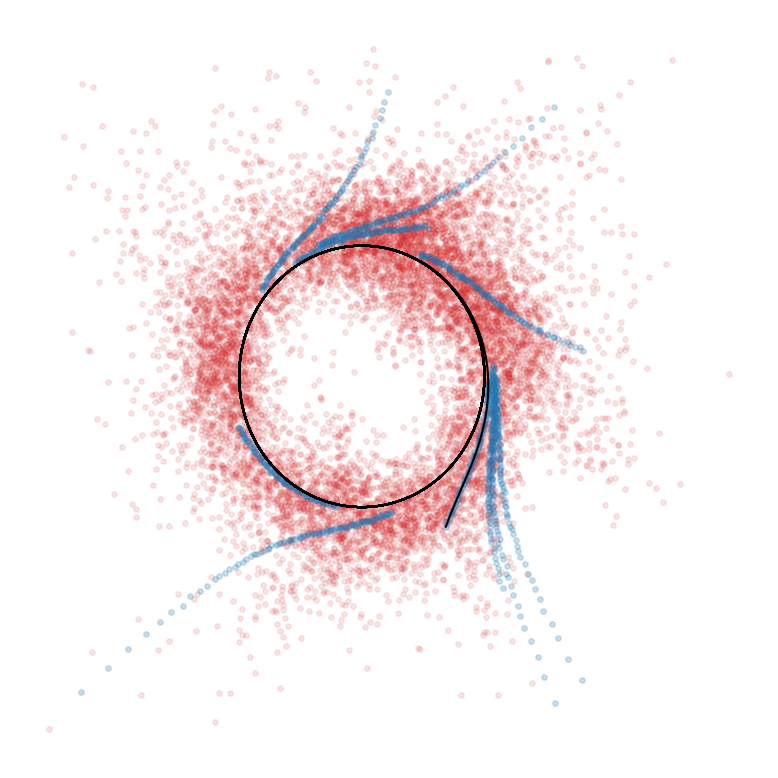

In [ ]:
# regenerate HF / LF datasets using the *absolute* noise levels from MF experiment
X_hf_noisy, t_train, _ = generate_hopf_dataset(
    n_traj=cfg.n_hf,
    T=1,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base,
)

X_lf_noisy, _, _ = generate_hopf_dataset(
    n_traj=cfg.n_lf,
    T=1,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base + 100,
)

# long clean reference trajectory (no noise)
X_ref, _, _ = generate_hopf_dataset(
    n_traj=1,
    T=100.0,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

# LF trajectories (noisy) – red
for X in X_lf_noisy:
    ax.plot(
        X[::10, 0],
        X[::10, 1],
        ".",
        color="tab:red",
        alpha=0.1,
        linewidth=0.6,
    )

# HF trajectories (noisy) – blue
for X in X_hf_noisy:
    ax.plot(
        X[::10, 0],
        X[::10, 1],
        ".",
        color="tab:blue",
        alpha=0.2,
        linewidth=0.8,
    )

# Clean reference trajectory – black
ax.plot(
    X_ref[0][:, 0],
    X_ref[0][:, 1],
    "-",
    color="black",
    alpha=1.0,
    linewidth=1.0,
)

# Remove ticks and spines for a clean, compact panel
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

plt.tight_layout(pad=0.05)
plt.show()


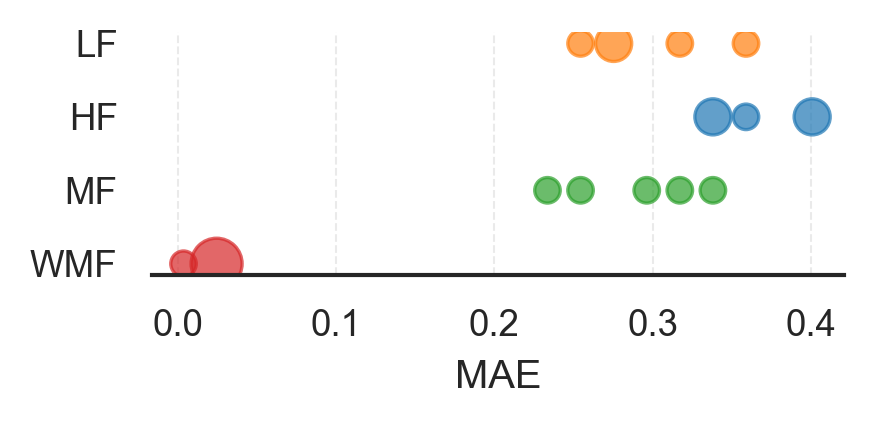

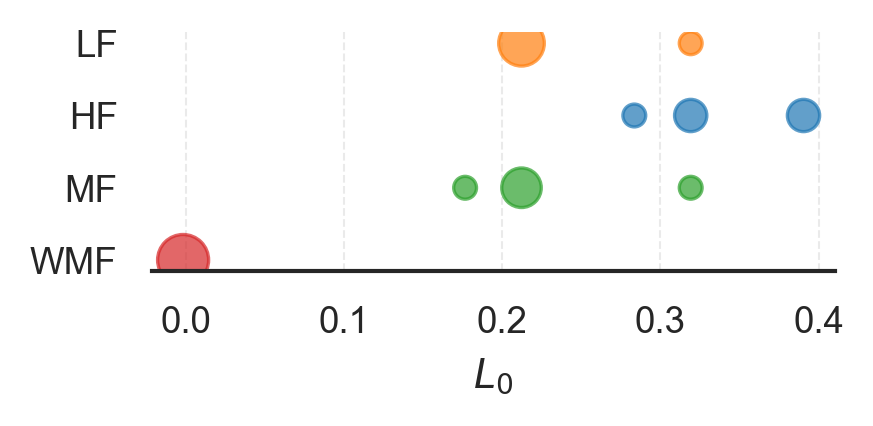

In [ ]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    # title=f"Burgers Part 1: MAE ({cfg.n_runs} runs)",
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    # title=f"Burgers Part 1: $L_0$ ({cfg.n_runs} runs)",
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

